# Principles of AI Lab - Complete Combined Notebook (Week 1 to Week 6)
All contents, markdown, code, comments, and outputs preserved.
Organized strictly in ascending week order.



---
# WEEK 1
---


# 230968272
# Vetsa Anuraga Chandan
## Week 3

# Experiment 2

In [1]:
import random

class GridEnvironment:
    def __init__(self):
        self.grid = [[random.choice([True, False]) for _ in range(2)] for _ in range(2)]
        self.agent_position = (random.randint(0, 1), random.randint(0, 1))

    def get_percept(self):
        x, y = self.agent_position
        return self.agent_position, self.grid[x][y]

    def move_agent(self, action):
        x, y = self.agent_position
        if action == "Up" and x > 0:
            self.agent_position = (x - 1, y)
        elif action == "Down" and x < 1:
            self.agent_position = (x + 1, y)
        elif action == "Left" and y > 0:
            self.agent_position = (x, y - 1)
        elif action == "Right" and y < 1:
            self.agent_position = (x, y + 1)

    def suck(self):
        x, y = self.agent_position
        if not self.grid[x][y]:
            self.grid[x][y] = True

    def is_clean(self, position):
        x, y = position
        return self.grid[x][y]



In [6]:
class SimpleReflexAgent:
    def __init__(self, environment):
        self.environment = environment
        self.cleaned_rooms = 0
        self.total_moves = 0

    def run(self, steps):
        for _ in range(steps):
            position, is_clean = self.environment.get_percept()
            if not is_clean:
                self.environment.suck()
                self.cleaned_rooms += 1
            else:
                self.random_move()

    def random_move(self):
        actions = ["Up", "Down", "Left", "Right"]
        valid_actions = []
        for action in actions:
            x, y = self.environment.agent_position
            if action == "Up" and x > 0:
                valid_actions.append(action)
            elif action == "Down" and x < 1:
                valid_actions.append(action)
            elif action == "Left" and y > 0:
                valid_actions.append(action)
            elif action == "Right" and y < 1:
                valid_actions.append(action)
        if valid_actions:
            action = random.choice(valid_actions)
            self.environment.move_agent(action)
            self.total_moves +=1 #does not consider suck as a movement 

env = GridEnvironment()
agent = SimpleReflexAgent(env)
steps = 20
agent.run(steps)

print(f"Number of rooms cleaned: {agent.cleaned_rooms}")
print(f"Total number of movements: {agent.total_moves}")


Number of rooms cleaned: 3
Total number of movements: 17


# Experiment 3

In [7]:
class GridEnvironment:
    def __init__(self, size=2):
        self.size = size
        self.grid = {
            (x, y): random.choice(["Dirty", "Clean"])
            for x in range(size)
            for y in range(size)
        }

    def get_status(self, position):
        return self.grid[position]

    def clean(self, position):
        self.grid[position] = "Clean"


In [8]:
class ModelBasedAgent:
    def __init__(self, environment):
        self.env = environment
        self.position = (random.randint(0, 1), random.randint(0, 1))
        self.model = {}
        self.movements = 0

    def perceive(self):
        return self.position, self.env.get_status(self.position)

    def update_model(self, percept):
        position, status = percept
        self.model[position] = status

    def all_rooms_clean(self):
        if len(self.model) < self.env.size ** 2:
            return False
        return all(status == "Clean" for status in self.model.values())

    def valid_moves(self):
        x, y = self.position
        moves = []

        if x > 0:
            moves.append(("Up", (x - 1, y)))
        if x < self.env.size - 1:
            moves.append(("Down", (x + 1, y)))
        if y > 0:
            moves.append(("Left", (x, y - 1)))
        if y < self.env.size - 1:
            moves.append(("Right", (x, y + 1)))

        return moves

    def choose_action(self):
        current_status = self.model[self.position]

        if current_status == "Dirty":
            return "Suck"

        moves = self.valid_moves()
Week
        for action, pos in moves:
            if pos not in self.model or self.model.get(pos) == "Dirty":
                return action

        return random.choice(moves)[0]

    def act(self, action):
        x, y = self.position

        if action == "Suck":
            self.env.clean(self.position)
            self.model[self.position] = "Clean"

        elif action == "Up":
            self.position = (x - 1, y)
            self.movements += 1

        elif action == "Down":
            self.position = (x + 1, y)
            self.movements += 1

        elif action == "Left":
            self.position = (x, y - 1)
            self.movements += 1

        elif action == "Right":
            self.position = (x, y + 1)
            self.movements += 1

    def run(self):
        while True:
            percept = self.perceive()
            self.update_model(percept)

            if self.all_rooms_clean():
                break

            action = self.choose_action()
            self.act(action)


In [9]:
def run_simulation():
    env = GridEnvironment()
    agent = ModelBasedAgent(env)
    agent.run()

    print("Model:", agent.model)
    print("Total movements:", agent.movements)


if __name__ == "__main__":
    run_simulation()

Model: {(0, 1): 'Clean', (1, 1): 'Clean', (1, 0): 'Clean', (0, 0): 'Clean'}
Total movements: 3



---
# WEEK 2
---


# 230968272
# Vetsa Anuraga Chandan
## Week 2

In [6]:
import random

class VacuumEnvironment:
    def __init__(self):
        self.rooms = {
            "A": random.choice(["Clean", "Dirty"]),
            "B": random.choice(["Clean", "Dirty"])
        }

    def get_status(self, location):
        return self.rooms[location]

    def update(self, location, action):
        if action == "Suck":
            self.rooms[location] = "Clean"

class ReflexVacuumAgent:
    def act(self, location, status):
        if status == "Dirty":
            return "Suck"
        if location == "A":
            return "Right"
        return "Left"

env = VacuumEnvironment()
agent = ReflexVacuumAgent()
agent_location = random.choice(["A", "B"])
steps = 10

for i in range(steps):
    status = env.get_status(agent_location)
    action = agent.act(agent_location, status)
    env.update(agent_location, action)
    if action == "Right":
        agent_location = "B"
    elif action == "Left":
        agent_location = "A"
    print(f"Step {i} | Action: {action}")


Step 0 | Action: Left
Step 1 | Action: Suck
Step 2 | Action: Right
Step 3 | Action: Left
Step 4 | Action: Right
Step 5 | Action: Left
Step 6 | Action: Right
Step 7 | Action: Left
Step 8 | Action: Right
Step 9 | Action: Left


## Experiment 2: Simple Reflex Agent in a 4-Room Grid Environment

In [7]:
class GridEnvironment:
    def __init__(self, size):
        self.size = size
        self.grid = {(x, y): "Dirty" for x in range(size) for y in range(size)}

    def get_status(self, position):
        return self.grid[position]

    def update(self, position, action):
        if action == "Suck":
            self.grid[position] = "Clean"

class ReflexAgent:
    def act(self, position, status, size):
        if status == "Dirty":
            return "Suck"
        moves = []
        x, y = position
        if x > 0: moves.append("Left")
        if x < size - 1: moves.append("Right")
        if y > 0: moves.append("Down")
        if y < size - 1: moves.append("Up")
        return random.choice(moves)

grid_size = 2
steps = 10

env = GridEnvironment(grid_size)
agent = ReflexAgent()
agent_pos = (0, 0)

for i in range(steps):
    status = env.get_status(agent_pos)
    action = agent.act(agent_pos, status, grid_size)
    print(f"Step {i} | Position: {agent_pos} | Status: {status} | Action: {action}")
    env.update(agent_pos, action)
    x, y = agent_pos
    if action == "Up":
        agent_pos = (x, y + 1)
    elif action == "Down":
        agent_pos = (x, y - 1)
    elif action == "Left":
        agent_pos = (x - 1, y)
    elif action == "Right":
        agent_pos = (x + 1, y)


Step 0 | Position: (0, 0) | Status: Dirty | Action: Suck
Step 1 | Position: (0, 0) | Status: Clean | Action: Right
Step 2 | Position: (1, 0) | Status: Dirty | Action: Suck
Step 3 | Position: (1, 0) | Status: Clean | Action: Left
Step 4 | Position: (0, 0) | Status: Clean | Action: Right
Step 5 | Position: (1, 0) | Status: Clean | Action: Up
Step 6 | Position: (1, 1) | Status: Dirty | Action: Suck
Step 7 | Position: (1, 1) | Status: Clean | Action: Left
Step 8 | Position: (0, 1) | Status: Dirty | Action: Suck
Step 9 | Position: (0, 1) | Status: Clean | Action: Down


## Experiment 3: Model-Based Vacuum Cleaner Agent

In [8]:
import random

class GridEnvironment:
    def __init__(self, size):
        self.size = size
        self.grid = {(x, y): "Dirty" for x in range(size) for y in range(size)}

    def get_status(self, position):
        return self.grid[position]

    def clean(self, position):
        self.grid[position] = "Clean"

class ModelBasedAgent:
    def __init__(self):
        self.model = {}

    def neighbors(self, position, size):
        x, y = position
        n = []
        if x > 0: n.append((x-1, y))
        if x < size - 1: n.append((x+1, y))
        if y > 0: n.append((x, y-1))
        if y < size - 1: n.append((x, y+1))
        return n

    def act(self, position, status, env):
        self.model[position] = status
        if status == "Dirty":
            self.model[position] = "Clean"
            return "Suck", position
        targets = [p for p in env.grid if self.model.get(p) != "Clean"]
        if not targets:
            return None, position
        options = [n for n in self.neighbors(position, env.size) if self.model.get(n) != "Clean"]
        if not options:
            options = self.neighbors(position, env.size)
        next_pos = random.choice(options)
        x, y = position
        nx, ny = next_pos
        if nx > x: action = "Right"
        elif nx < x: action = "Left"
        elif ny > y: action = "Up"
        else: action = "Down"
        return action, next_pos

grid_size = 2
steps = 10

env = GridEnvironment(grid_size)
agent = ModelBasedAgent()
agent_pos = (0, 0)

for i in range(steps):
    status = env.get_status(agent_pos)
    action, new_pos = agent.act(agent_pos, status, env)
    if action is None:
        print(f"Step {i} | All rooms clean")
        break
    print(f"Step {i} | Position: {agent_pos} | Action: {action}")
    if action == "Suck":
        env.clean(agent_pos)
    else:
        agent_pos = new_pos


Step 0 | Position: (0, 0) | Action: Suck
Step 1 | Position: (0, 0) | Action: Up
Step 2 | Position: (0, 1) | Action: Suck
Step 3 | Position: (0, 1) | Action: Right
Step 4 | Position: (1, 1) | Action: Suck
Step 5 | Position: (1, 1) | Action: Down
Step 6 | Position: (1, 0) | Action: Suck
Step 7 | All rooms clean


## 1. Why does the simple reflex agent perform redundant actions?

The simple reflex agent has no memory of past states or actions. Its decisions depend only on the current percept, so it cannot distinguish between rooms that have already been cleaned and those that have not. As a result, it may revisit clean rooms and perform unnecessary movements, leading to redundant actions.

## 2. How does the internal model improve agent performance?

The internal model allows the agent to store information about the cleanliness of rooms it has already visited. By using this stored knowledge, the agent can avoid revisiting rooms known to be clean and can prioritize moving toward dirty or unvisited rooms. This reduces unnecessary movements and improves overall efficiency.

## 3. Compare the simple reflex and model-based agents

### a. Rationality
The model-based agent is more rational because it uses both current percepts and past information to choose actions that better achieve the goal of cleaning all rooms efficiently.

### b. Efficiency
The model-based agent is more efficient since it minimizes redundant movements and completes the task using fewer actions compared to the simple reflex agent.

### c. Scalability
The model-based agent scales better in larger or more complex environments because its internal model helps manage increasing state complexity, whereas the simple reflex agent becomes increasingly inefficient as the environment grows.

## 4. Would the model-based agent work correctly in a partially observable environment? Justify.

In a partially observable environment, the model-based agent may not work correctly because its internal model relies on accurate and complete percepts. If the agent receives incomplete or incorrect information, the model can become inaccurate, leading to suboptimal or incorrect decisions unless additional mechanisms such as belief states or probabilistic reasoning are used.


---
# WEEK 3
---


## Abhyuday K Purohit
## Week 3
## 230968144

# LAB-2: INTELLIGENT AGENTS AND ENVIRONMENTS

## Experiment 1: Smart Thermostat Agent (Reactive Agent)

In [1]:

states = ["Low", "Comfortable", "High"]

def thermostat_agent(state):
    if state == "Low":
        return "Heat"
    elif state == "High":
        return "Cool"
    else:
        return "Idle"

def environment(state, action):
    index = states.index(state)
    if action == "Heat" and index < 2:
        return states[index + 1]
    elif action == "Cool" and index > 0:
        return states[index - 1]
    return state

initial_states = ["Low", "Comfortable", "High"]
for state in initial_states:
    print(f"Starting State: {state}")
    for step in range(3):
        action = thermostat_agent(state)
        print(f" Step {step+1}: State={state}, Action={action}")
        state = environment(state, action)


Starting State: Low
 Step 1: State=Low, Action=Heat
 Step 2: State=Comfortable, Action=Idle
 Step 3: State=Comfortable, Action=Idle
Starting State: Comfortable
 Step 1: State=Comfortable, Action=Idle
 Step 2: State=Comfortable, Action=Idle
 Step 3: State=Comfortable, Action=Idle
Starting State: High
 Step 1: State=High, Action=Cool
 Step 2: State=Comfortable, Action=Idle
 Step 3: State=Comfortable, Action=Idle


## Experiment 2: Elevator Control Agent (Goal-Based Agent)

In [2]:

def elevator_agent(current_floor, request_floor):
    if current_floor < request_floor:
        return "Move Up"
    elif current_floor > request_floor:
        return "Move Down"
    else:
        return "Stay"

scenarios = [(1, 3), (3, 2), (2, 2)]
for current, request in scenarios:
    print(f"Request at Floor {request}")
    while current != request:
        action = elevator_agent(current, request)
        print(f" Elevator at Floor {current} -> {action}")
        current += 1 if action == "Move Up" else -1
    print(" Reached Floor", current)


Request at Floor 3
 Elevator at Floor 1 -> Move Up
 Elevator at Floor 2 -> Move Up
 Reached Floor 3
Request at Floor 2
 Elevator at Floor 3 -> Move Down
 Reached Floor 2
Request at Floor 2
 Reached Floor 2


## Experiment 3: Autonomous Traffic Signal Agent

In [3]:

def traffic_signal_agent(roadA, roadB):
    if roadA == "High" and roadB == "Low":
        return "Green for Road A"
    elif roadB == "High" and roadA == "Low":
        return "Green for Road B"
    else:
        return "Green for Road A"

scenarios = [("High", "Low"), ("Low", "High"), ("High", "High")]
for A, B in scenarios:
    print(f"Road A: {A}, Road B: {B} -> {traffic_signal_agent(A, B)}")


Road A: High, Road B: Low -> Green for Road A
Road A: Low, Road B: High -> Green for Road B
Road A: High, Road B: High -> Green for Road A


## Experiment 4: Warehouse Robot Navigation Agent

In [4]:

grid = [
    [0, 0, 1],
    [0, 0, 0],
    [1, 0, 0]
]

start = (0, 0)
goal = (2, 2)
visited = set()
position = start

moves = [(0,1),(1,0),(0,-1),(-1,0)]

while position != goal:
    visited.add(position)
    print("Robot at:", position)
    for move in moves:
        next_pos = (position[0]+move[0], position[1]+move[1])
        if (0 <= next_pos[0] < 3 and
            0 <= next_pos[1] < 3 and
            grid[next_pos[0]][next_pos[1]] == 0 and
            next_pos not in visited):
            position = next_pos
            break

print("Item picked at:", position)


Robot at: (0, 0)
Robot at: (0, 1)
Robot at: (1, 1)
Robot at: (1, 2)
Item picked at: (2, 2)


## Experiment 5: Online Recommendation Agent (Learning Agent)

In [5]:

scores = {"A": 0, "B": 0}

def recommend():
    return max(scores, key=scores.get)

def learn(product, feedback):
    if feedback == "like":
        scores[product] += 1
    else:
        scores[product] -= 1

feedbacks = [("A","like"), ("B","dislike"), ("A","like"), ("B","like")]
for product, feedback in feedbacks:
    learn(product, feedback)
    print("Scores:", scores, "Next Recommendation:", recommend())


Scores: {'A': 1, 'B': 0} Next Recommendation: A
Scores: {'A': 1, 'B': -1} Next Recommendation: A
Scores: {'A': 2, 'B': -1} Next Recommendation: A
Scores: {'A': 2, 'B': 0} Next Recommendation: A



---
# WEEK 4.1
---


# 230968144 Abhyuday K Purohit

# Experiment 1: Breadth-First Search (BFS) – Maze Navigation


In [ ]:
from collections import deque

def bfs(graph, start, goal):
    queue = deque([[start]])     # store paths
    visited = set()
    nodes_expanded = 0

    while queue:
        path = queue.popleft()
        node = path[-1]

        if node == goal:
            return path, nodes_expanded

        if node not in visited:
            visited.add(node)
            nodes_expanded += 1

            for neighbor in graph[node]:
                new_path = path + [neighbor]
                queue.append(new_path)

    return None, nodes_expanded


In [2]:
maze = {
    'A': ['B', 'C'],
    'B': ['A', 'D', 'E'],
    'C': ['A', 'F'],
    'D': ['B'],
    'E': ['B', 'F'],
    'F': ['C', 'E', 'G'],
    'G': []
}

path, expanded = bfs(maze, 'A', 'G')
print("Path found:", path)
print("Nodes expanded:", expanded)


Path found: ['A', 'C', 'F', 'G']
Nodes expanded: 6


# Experiment 2: Depth-First Search (DFS) – Graph Traversal

## Recursive DFS Implementation

In [3]:
def dfs(graph, current, goal, path, visited):
    path.append(current)
    visited.add(current)

    if current == goal:
        return path

    for neighbor in graph[current]:
        if neighbor not in visited:
            result = dfs(graph, neighbor, goal, path.copy(), visited)
            if result:
                return result

    return None


In [4]:
visited = set()
path = dfs(maze, 'A', 'G', [], visited)
print("Path found:", path)


Path found: ['A', 'B', 'E', 'F', 'G']


# Experiment 3: 8-Puzzle Problem Using BFS

## State Representation

In [5]:
initial_state = (1, 2, 3,
                 4, 0, 5,
                 6, 7, 8)

goal_state = (1, 2, 3,
              4, 5, 6,
              7, 8, 0)


## Valid Moves Generator

In [6]:
def get_neighbors(state):
    neighbors = []
    idx = state.index(0)
    row, col = divmod(idx, 3)

    moves = [(-1,0),(1,0),(0,-1),(0,1)]

    for dr, dc in moves:
        r, c = row + dr, col + dc
        if 0 <= r < 3 and 0 <= c < 3:
            new_idx = r * 3 + c
            new_state = list(state)
            new_state[idx], new_state[new_idx] = new_state[new_idx], new_state[idx]
            neighbors.append(tuple(new_state))

    return neighbors


## BFS for 8-Puzzle

In [7]:
from collections import deque

def bfs_8_puzzle(start, goal):
    queue = deque([[start]])
    visited = set([start])
    expanded = 0

    while queue:
        path = queue.popleft()
        state = path[-1]

        if state == goal:
            return path, expanded

        expanded += 1
        for neighbor in get_neighbors(state):
            if neighbor not in visited:
                visited.add(neighbor)
                queue.append(path + [neighbor])

    return None, expanded


In [8]:
path, expanded = bfs_8_puzzle(initial_state, goal_state)

print("Steps:")
for p in path:
    print(p)

print("States expanded:", expanded)


Steps:
(1, 2, 3, 4, 0, 5, 6, 7, 8)
(1, 2, 3, 4, 5, 0, 6, 7, 8)
(1, 2, 3, 4, 5, 8, 6, 7, 0)
(1, 2, 3, 4, 5, 8, 6, 0, 7)
(1, 2, 3, 4, 5, 8, 0, 6, 7)
(1, 2, 3, 0, 5, 8, 4, 6, 7)
(1, 2, 3, 5, 0, 8, 4, 6, 7)
(1, 2, 3, 5, 6, 8, 4, 0, 7)
(1, 2, 3, 5, 6, 8, 4, 7, 0)
(1, 2, 3, 5, 6, 0, 4, 7, 8)
(1, 2, 3, 5, 0, 6, 4, 7, 8)
(1, 2, 3, 0, 5, 6, 4, 7, 8)
(1, 2, 3, 4, 5, 6, 0, 7, 8)
(1, 2, 3, 4, 5, 6, 7, 0, 8)
(1, 2, 3, 4, 5, 6, 7, 8, 0)
States expanded: 6026


# Experiment 4: BFS vs DFS Performance Comparison

## Instrumented BFS & DFS

## BFS

In [13]:
graph = {
    'A': ['B', 'C'],
    'B': ['D', 'E'],
    'C': ['F'],
    'D': [],
    'E': ['F'],
    'F': ['G'],
    'G': []
}

start = 'A'
goal = 'G'


In [14]:
from collections import deque
import time

def bfs_performance(graph, start, goal):
    queue = deque([[start]])
    visited = set()
    nodes_expanded = 0

    start_time = time.time()

    while queue:
        path = queue.popleft()
        node = path[-1]

        if node == goal:
            end_time = time.time()
            return {
                "path": path,
                "nodes_expanded": nodes_expanded,
                "time": end_time - start_time,
                "memory": len(queue)
            }

        if node not in visited:
            visited.add(node)
            nodes_expanded += 1

            for neighbor in graph[node]:
                queue.append(path + [neighbor])

    return None


In [15]:
bfs_result = bfs_performance(graph, start, goal)

print("BFS Path:", bfs_result["path"])
print("BFS Nodes Expanded:", bfs_result["nodes_expanded"])
print("BFS Execution Time:", bfs_result["time"])
print("BFS Memory Used:", bfs_result["memory"])


BFS Path: ['A', 'C', 'F', 'G']
BFS Nodes Expanded: 6
BFS Execution Time: 4.291534423828125e-06
BFS Memory Used: 0


## DFS

In [17]:
import time

def dfs_performance(graph, node, goal, visited, depth=0):
    visited.add(node)

    if node == goal:
        return True, depth

    for neighbor in graph[node]:
        if neighbor not in visited:
            found, d = dfs_performance(graph, neighbor, goal, visited, depth + 1)
            if found:
                return True, d

    return False, depth


In [18]:
visited = set()
start_time = time.time()
found, max_depth = dfs_performance(graph, start, goal, visited)
end_time = time.time()

print("DFS Path Found:", found)
print("DFS Nodes Expanded:", len(visited))
print("DFS Execution Time:", end_time - start_time)
print("DFS Memory Used (Depth):", max_depth)


DFS Path Found: True
DFS Nodes Expanded: 6
DFS Execution Time: 2.47955322265625e-05
DFS Memory Used (Depth): 4


1. Why does BFS guarantee an optimal solution while DFS does not?

BFS explores the search space level by level, expanding all nodes at depth d before moving to d + 1.
In an unweighted graph, the first time BFS reaches the goal, it has found the shortest possible path (minimum number of steps).

DFS, on the other hand, dives deep into one branch without considering path length. It may find a solution quickly, but that solution can be longer than necessary, so optimality is not guaranteed.

2. In which scenarios is DFS preferred over BFS?

DFS is preferred when:

Memory is limited, since DFS stores only the current path and recursion stack.

The solution is deep in the search tree.

Any solution is acceptable and optimality is not required.

The branching factor is large, making BFS memory-expensive.

In short: DFS is chosen for space efficiency, not solution quality.

3. How does the branching factor affect BFS performance?

The branching factor (b) directly causes exponential growth in BFS.

At depth d, BFS may need to explore up to
O(bᵈ) nodes.

As b increases:

Time complexity increases exponentially.

Memory usage explodes because BFS stores all frontier nodes.

Even a small increase in branching factor can make BFS infeasible.

4. Why is BFS considered impractical for large state spaces?

BFS is impractical for large state spaces because:

It must store all generated nodes at each level.

Memory requirements grow exponentially with depth.

For large or infinite state spaces, BFS can run out of memory before reaching the goal.

Thus, despite being optimal, BFS often fails due to space limitations.


---
# WEEK 4.2
---


# 230968144 Abhyuday K Purohit 

# INFORMED SEARCH ALGORITHMS

In [1]:
maze = {
    'A': ['B', 'C'],
    'B': ['A', 'D', 'E'],
    'C': ['A', 'F'],
    'D': ['B'],
    'E': ['B', 'F'],
    'F': ['C', 'E', 'G'],
    'G': []
}


# Node Coordinates (for Manhattan Distance)

In [11]:
coords = {
    'A': (0,0),
    'B': (1,0),
    'C': (0,1),
    'D': (2,0),
    'E': (1,1),
    'F': (0,2),
    'G': (1,2)
}

start = 'A'
goal = 'G'


# Greedy Best-First Search

In [12]:
def manhattan(n):
    x1, y1 = coords[n]
    x2, y2 = coords[goal]
    return abs(x1 - x2) + abs(y1 - y2)


In [13]:
import heapq

def greedy_best_first(graph, start, goal):
    pq = []
    heapq.heappush(pq, (manhattan(start), [start]))
    visited = set()
    nodes_expanded = 0

    while pq:
        _, path = heapq.heappop(pq)
        node = path[-1]

        if node == goal:
            return path, nodes_expanded

        if node not in visited:
            visited.add(node)
            nodes_expanded += 1

            for neighbor in graph[node]:
                if neighbor not in visited:
                    heapq.heappush(
                        pq,
                        (manhattan(neighbor), path + [neighbor])
                    )

    return None, nodes_expanded


In [14]:
path, expanded = greedy_best_first(maze, start, goal)
print("Greedy Path:", path)
print("Nodes Expanded:", expanded)


Greedy Path: ['A', 'B', 'E', 'F', 'G']
Nodes Expanded: 4


# A* Search Algorithm

In [15]:
def a_star(graph, start, goal):
    pq = []
    heapq.heappush(pq, (manhattan(start), 0, [start]))
    visited = {}
    nodes_expanded = 0

    while pq:
        f, g, path = heapq.heappop(pq)
        node = path[-1]

        if node == goal:
            return path, nodes_expanded

        if node not in visited or g < visited[node]:
            visited[node] = g
            nodes_expanded += 1

            for neighbor in graph[node]:
                new_g = g + 1
                new_f = new_g + manhattan(neighbor)
                heapq.heappush(
                    pq,
                    (new_f, new_g, path + [neighbor])
                )

    return None, nodes_expanded


In [16]:
path, expanded = a_star(maze, start, goal)
print("A* Path:", path)
print("Nodes Expanded:", expanded)


A* Path: ['A', 'C', 'F', 'G']
Nodes Expanded: 5


# Comparison of BFS, Greedy Best-First Search, and A* Search

Path Length Found

BFS finds the shortest path because it explores level by level.

Greedy Best-First Search may find a short path, but it is not guaranteed to be the shortest.

A* always finds the shortest (optimal) path when the heuristic is admissible.

Nodes Expanded

BFS expands the maximum number of nodes because it explores all nodes at each depth.

Greedy Best-First Search expands fewer nodes since it directly moves toward the goal using heuristic information.

A* expands the fewest nodes by balancing path cost and heuristic estimate.

Optimality of Solution

BFS → Optimal (for unweighted graphs)

Greedy Best-First Search → Not optimal

A* → Optimal (with admissible heuristic)

Efficiency

BFS is time- and memory-intensive.

Greedy Best-First Search is fast but unreliable.

A* is the most efficient overall, offering both speed and optimality.

In [17]:
import pandas as pd

data = {
    "Algorithm": ["BFS", "Greedy Best-First Search", "A* Search"],
    "Path Length Found": ["Shortest", "May not be shortest", "Shortest"],
    "Nodes Expanded": ["High", "Low", "Very Low"],
    "Optimality": ["Yes", "No", "Yes"],
    "Efficiency": ["Low", "High", "Very High"]
}

df = pd.DataFrame(data)
df


,Algorithm,Path Length Found,Nodes Expanded,Optimality,Efficiency
0,BFS,Shortest,High,Yes,Low
1,Greedy Best-First Search,May not be shortest,Low,No,High
2,A* Search,Shortest,Very Low,Yes,Very High



---
# WEEK 5
---


# Abhyuday K Purohit 230968144

# Experiment 4a

Aim

To understand and implement memory-bounded heuristic search algorithms:

Recursive Best-First Search (RBFS)

Iterative Deepening A* (IDA*)

Simplified Memory-Bounded A* (SMA*)

## Problem Setup

In [2]:
maze = {
    'A': ['B', 'C'],
    'B': ['A', 'D', 'E'],
    'C': ['A', 'F'],
    'D': ['B'],
    'E': ['B', 'F'],
    'F': ['C', 'E', 'G'],
    'G': []
}

coords = {
    'A': (0,0),
    'B': (1,0),
    'C': (0,1),
    'D': (2,0),
    'E': (1,1),
    'F': (0,2),
    'G': (1,2)
}

start = 'A'
goal = 'G'


## Manhattan Distance Heuristic

In [3]:
def h(n):
    x1, y1 = coords[n]
    x2, y2 = coords[goal]
    return abs(x1 - x2) + abs(y1 - y2)


## Experiment 4: Recursive Best-First Search (RBFS)

In [ ]:
Problem Formulation

State space: Maze nodes

Initial state: A

Goal test: Node == G

Path cost: Uniform cost = 1

Evaluation function:

𝑓(𝑛)=𝑔(𝑛)+ℎ(𝑛)

Memory usage: Linear (recursion stack only)

In [4]:
nodes_expanded_rbfs = 0

def rbfs(node, path, g, f_limit):
    global nodes_expanded_rbfs
    nodes_expanded_rbfs += 1

    if node == goal:
        return path, g

    successors = []
    for neighbor in maze[node]:
        if neighbor not in path:
            f = g + 1 + h(neighbor)
            successors.append((f, neighbor))

    if not successors:
        return None, float('inf')

    while True:
        successors.sort()
        best_f, best_node = successors[0]

        if best_f > f_limit:
            return None, best_f

        alternative = successors[1][0] if len(successors) > 1 else float('inf')

        result, best_f = rbfs(
            best_node,
            path + [best_node],
            g + 1,
            min(f_limit, alternative)
        )

        successors[0] = (best_f, best_node)

        if result is not None:
            return result, best_f


## Run RBFS

In [6]:
nodes_expanded_rbfs = 0
path, cost = rbfs(start, [start], 0, float('inf'))

print("RBFS Path:", path)
print("RBFS Cost:", cost)
print("RBFS Nodes Expanded:", nodes_expanded_rbfs)


RBFS Path: ['A', 'C', 'F', 'G']
RBFS Cost: 3
RBFS Nodes Expanded: 6


## Experiment 5: Iterative Deepening A* (IDA*)
Idea

DFS + A* cost function

Repeatedly increases cost threshold

Uses very little memory

## IDA* Implementation

In [8]:
nodes_expanded_ida = 0

def ida_search(path, g, threshold):
    global nodes_expanded_ida
    node = path[-1]
    f = g + h(node)

    if f > threshold:
        return f
    if node == goal:
        return "FOUND"

    min_cost = float('inf')
    nodes_expanded_ida += 1

    for neighbor in maze[node]:
        if neighbor not in path:
            path.append(neighbor)
            temp = ida_search(path, g + 1, threshold)

            if temp == "FOUND":
                return "FOUND"

            if temp < min_cost:
                min_cost = temp

            path.pop()

    return min_cost


## Run IDA*

In [9]:
threshold = h(start)
path = [start]
nodes_expanded_ida = 0

while True:
    temp = ida_search(path, 0, threshold)
    if temp == "FOUND":
        break
    threshold = temp

print("IDA* Path:", path)
print("IDA* Cost:", len(path) - 1)
print("IDA* Nodes Expanded:", nodes_expanded_ida)





IDA* Path: ['A', 'C', 'F', 'G']
IDA* Cost: 3
IDA* Nodes Expanded: 5


# Experiment 6: Simplified Memory-Bounded A* (SMA*)

Idea

A* with fixed memory limit

Drops worst nodes when memory is full

Optimal if memory is sufficient

# SMA* Implementation (Simplified)

In [10]:
import heapq

def sma_star(memory_limit=5):
    open_list = []
    heapq.heappush(open_list, (h(start), 0, [start]))
    nodes_expanded = 0

    while open_list:
        if len(open_list) > memory_limit:
            open_list.sort(reverse=True)
            open_list.pop()

        f, g, path = heapq.heappop(open_list)
        node = path[-1]
        nodes_expanded += 1

        if node == goal:
            return path, g, nodes_expanded

        for neighbor in maze[node]:
            if neighbor not in path:
                new_g = g + 1
                new_f = new_g + h(neighbor)
                heapq.heappush(
                    open_list,
                    (new_f, new_g, path + [neighbor])
                )

    return None, None, nodes_expanded


# Run SMA*

In [11]:
path, cost, expanded = sma_star(memory_limit=5)

print("SMA* Path:", path)
print("SMA* Cost:", cost)
print("SMA* Nodes Expanded:", expanded)


SMA* Path: ['A', 'C', 'F', 'G']
SMA* Cost: 3
SMA* Nodes Expanded: 6


In [12]:
import pandas as pd

data = {
    "Algorithm": ["RBFS", "IDA*", "SMA*"],
    "Memory Usage": ["Linear", "Very Low", "Fixed Limit"],
    "Optimal": ["Yes", "Yes", "Yes (if enough memory)"],
    "Nodes Expanded": ["Medium", "High", "Low"],
    "Efficiency": ["High", "Medium", "High"]
}

pd.DataFrame(data)


,Algorithm,Memory Usage,Optimal,Nodes Expanded,Efficiency
0,RBFS,Linear,Yes,Medium,High
1,IDA*,Very Low,Yes,High,Medium
2,SMA*,Fixed Limit,Yes (if enough memory),Low,High



---
# WEEK 6
---


# 239068144 Abhyuday k Purohit 

# Week 6

Problem Statement: You are given a dataset (select a random dataset) with multiple input
features and a target variable. Each state represents a subset of selected features. The goal is
to find a feature subset that maximizes model accuracy.
State Representation

A binary vector indicating whether a feature is selected (1) or not (0)
Initial State

A randomly generated feature subset
Neighbor Generation

Flip one bit (add/remove one feature)
Evaluation Function

Cross-validation accuracy of a simple classifier (e.g., Logistic Regression)
Algorithm Implementation
Implement steepest-ascent hill climbing
Stop when no neighbor improves the current solution
Experimentation

Run the algorithm multiple times with different random initial states

# Exercise 1: Hill Climbing for Feature Selection

In [13]:
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
import random

# Load dataset
data = load_breast_cancer()
X = data.data
y = data.target
n_features = X.shape[1]

def evaluate(state):
    selected = [i for i in range(n_features) if state[i] == 1]
    if len(selected) == 0:
        return 0
    X_subset = X[:, selected]
    model = LogisticRegression(max_iter=5000)
    return cross_val_score(model, X_subset, y, cv=5).mean()

def get_neighbors(state):
    neighbors = []
    for i in range(n_features):
        neighbor = state.copy()
        neighbor[i] = 1 - neighbor[i]  # flip bit
        neighbors.append(neighbor)
    return neighbors

def hill_climbing():
    current = np.random.randint(0, 2, n_features)
    current_score = evaluate(current)

    while True:
        neighbors = get_neighbors(current)
        scores = [evaluate(n) for n in neighbors]
        best_score = max(scores)

        if best_score <= current_score:
            break

        best_neighbor = neighbors[scores.index(best_score)]
        current = best_neighbor
        current_score = best_score

    return current, current_score


In [14]:
for i in range(5):
    solution, score = hill_climbing()
    print(f"Run {i+1}: Accuracy = {score}")


Run 1: Accuracy = 0.9578171091445427
Run 2: Accuracy = 0.9595870206489675
Run 3: Accuracy = 0.9560627231796305
Run 4: Accuracy = 0.9595870206489675
Run 5: Accuracy = 0.9560627231796305


# Exercise 2: Simulated Annealing for Vehicle Routing (TSP style)

Initial Cost: 1008.4660872869465
Final Cost: 460.277961255088


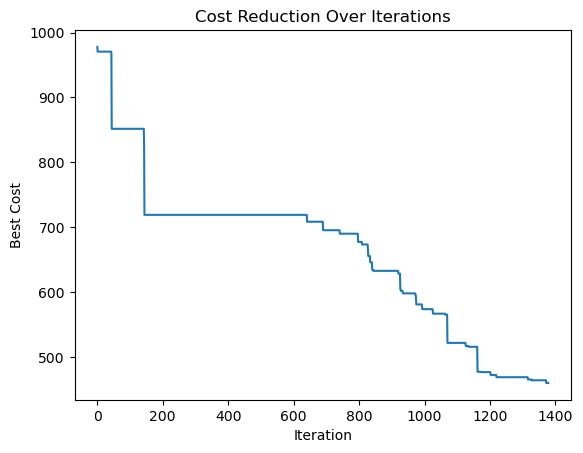

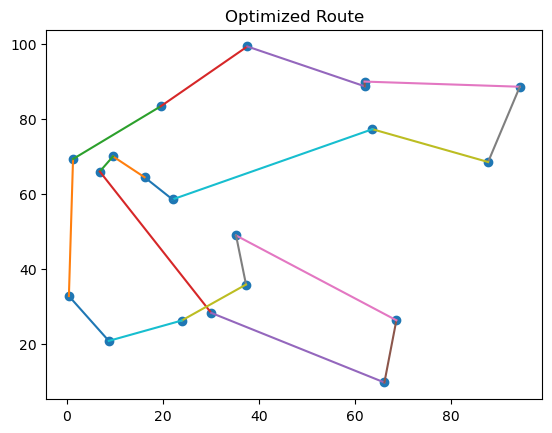

In [15]:
import numpy as np
import random
import math
import matplotlib.pyplot as plt

# ----- Generate Cities -----
n_cities = 20
cities = np.random.rand(n_cities, 2) * 100

def route_distance(route):
    total = 0
    for i in range(len(route)):
        total += np.linalg.norm(cities[route[i]] - cities[route[(i+1)%n_cities]])
    return total

def simulated_annealing():
    current = list(range(n_cities))
    random.shuffle(current)
    best = current.copy()

    current_cost = route_distance(current)
    best_cost = current_cost

    T = 1000
    cooling = 0.995

    costs = []

    while T > 1:
        i, j = random.sample(range(n_cities), 2)
        neighbor = current.copy()
        neighbor[i], neighbor[j] = neighbor[j], neighbor[i]

        new_cost = route_distance(neighbor)
        delta = new_cost - current_cost

        if delta < 0 or random.random() < math.exp(-delta / T):
            current = neighbor
            current_cost = new_cost

            if current_cost < best_cost:
                best = current
                best_cost = current_cost

        costs.append(best_cost)
        T *= cooling

    return best, best_cost, costs

# ----- Run -----
initial_route = list(range(n_cities))
random.shuffle(initial_route)

initial_cost = route_distance(initial_route)

best_route, best_cost, cost_progress = simulated_annealing()

print("Initial Cost:", initial_cost)
print("Final Cost:", best_cost)

# ----- Visualization -----
plt.figure()
plt.plot(cost_progress)
plt.title("Cost Reduction Over Iterations")
plt.xlabel("Iteration")
plt.ylabel("Best Cost")
plt.show()

plt.figure()
plt.scatter(cities[:,0], cities[:,1])

route = best_route + [best_route[0]]
for i in range(len(route)-1):
    plt.plot([cities[route[i]][0], cities[route[i+1]][0]],
             [cities[route[i]][1], cities[route[i+1]][1]])

plt.title("Optimized Route")
plt.show()


# Exercise 3: Genetic Algorithm for Drone Path Planning

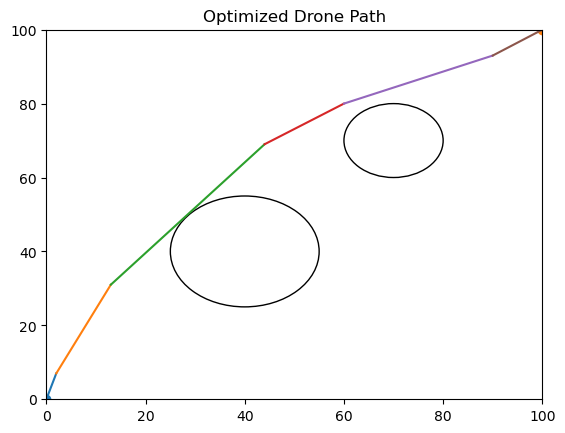

In [16]:
import numpy as np
import random
import matplotlib.pyplot as plt

MAP_SIZE = 100
WAYPOINTS = 5
POP_SIZE = 50
GENERATIONS = 100

start = (0, 0)
end = (100, 100)

# Obstacles (x, y, radius)
obstacles = [(40, 40, 15), (70, 70, 10)]

def random_path():
    return [(random.randint(0, MAP_SIZE),
             random.randint(0, MAP_SIZE)) for _ in range(WAYPOINTS)]

def line_intersects_circle(p1, p2, cx, cy, r):
    p1 = np.array(p1)
    p2 = np.array(p2)
    center = np.array([cx, cy])
    line = p2 - p1
    t = np.dot(center - p1, line) / np.dot(line, line)
    t = max(0, min(1, t))
    closest = p1 + t * line
    return np.linalg.norm(closest - center) < r

def fitness(path):
    full = [start] + path + [end]
    total = 0
    penalty = 0

    for i in range(len(full)-1):
        total += np.linalg.norm(np.array(full[i]) - np.array(full[i+1]))
        for (cx, cy, r) in obstacles:
            if line_intersects_circle(full[i], full[i+1], cx, cy, r):
                penalty += 1000

    return -(total + penalty)

def tournament(pop):
    return max(random.sample(pop, 3), key=fitness)

def crossover(p1, p2):
    point = random.randint(1, WAYPOINTS-1)
    return p1[:point] + p2[point:]

def mutate(path):
    i = random.randint(0, WAYPOINTS-1)
    path[i] = (random.randint(0, MAP_SIZE),
               random.randint(0, MAP_SIZE))
    return path

def genetic_algorithm():
    population = [random_path() for _ in range(POP_SIZE)]

    for _ in range(GENERATIONS):
        new_pop = []
        for _ in range(POP_SIZE):
            p1 = tournament(population)
            p2 = tournament(population)
            child = crossover(p1, p2)
            if random.random() < 0.1:
                child = mutate(child)
            new_pop.append(child)
        population = new_pop

    return max(population, key=fitness)

best_path = genetic_algorithm()

# ----- Visualization -----
plt.figure()

# Plot obstacles
for (cx, cy, r) in obstacles:
    circle = plt.Circle((cx, cy), r, fill=False)
    plt.gca().add_patch(circle)

# Plot path
full = [start] + best_path + [end]
for i in range(len(full)-1):
    plt.plot([full[i][0], full[i+1][0]],
             [full[i][1], full[i+1][1]])

plt.scatter(*start)
plt.scatter(*end)

plt.xlim(0, MAP_SIZE)
plt.ylim(0, MAP_SIZE)
plt.title("Optimized Drone Path")
plt.show()


1. Why does hill climbing fail sometimes?

Because it’s greedy. It gets trapped in local maxima and has no escape mechanism.

2. Why does simulated annealing work better?

Because it probabilistically accepts worse solutions early on, allowing escape from local minima.

3. Why does temperature decrease?

To gradually reduce randomness and shift from exploration → exploitation.

4. Why use tournament selection in GA?

It maintains diversity while favoring fitter individuals.

5. What happens if mutation rate is too high?

The search becomes random. Evolution collapses into chaos.

6. What happens if mutation rate is too low?

Population converges prematurely. You get genetic stagnation.

7. What is convergence?

When improvements stop over generations.

8. Time complexity?

SA: O(iterations × cost_eval)

GA: O(generations × population × fitness_eval)